In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import matplotlib.dates as mdates
import statsmodels.formula.api as smf

# Housing trends through the lens of interest rates

## Introduction

Currently I am a 2nd year economics and finance student and last semester I had a very interesting course called "Money, banking and financial markets". 
The core of the course was to understand the role of the monetary policy as a tool to stabilize the economy.

We discussed a lot how central banks change the nominal interest rate to influence the demand for money. The banks generally do that when the inflation target is not equal to the real inflation.

#### The Economic Theory

To understand and analyze the relationship between interest rates and housing prices, we first must understand the **Monetary Transmission Mechanism**.

When there is high inflation that generally means that people have a lot of money on their hands and spend a lot. That causes prices of goods and services to rise. That is a signal that the economy is "overheating". To prevent inflation going higher, central banks raise their Policy rates (interest rates). As interest rates rise:  

**Cost of borrowing**: Borrowing money becomes more expensive, therefore reducing the demand for mortgages. As a result, less people get mortgages and less people are buying real estate. 

**Opportunity cost**: Savings accounts become more lucrative, which incentives people to save their money than to spend them on the economy and therefore real estate.

**"Policy rate" Assumption**:
In this project, when I mention the Interest rate, I am referring to the general sense used in economic theory. We assume that "Policy Rate" set by a Central Bank trickles down to all other types of rates. By using one rate, I am looking at the overall "price of money" in that country.

Even though, interest rates are important litmus test for the behavior of housing prices, they aren't the only factor. To isolate their magnitude, we must take into consideration other macroeconomic 'confounders'. I have chosen the following:  

**GDP Growth**:  The growth of a countries economy. The idea is that as an economy grows, so too does the housing demand  

**Unemployment**: Represents job security. High unemployment reduces the pool of eligible mortgage borrowers. 

## Research Problem 

In class we studied the theoretical economic theory that explains the interest rates as tool to stabilize the economy, but this project will focus on the real-life application of the interest rate in terms of one of the most sought after social and material assets - residential real estate.

The core research questions, that I aim to answer:

1. **Global sensitivity to the effect**: Is there a universal significant inverse relationship between real interest rates and housing price growth on a global scale?
2. **Economic Differences**: Is the sensitivity to the effect different between "Developed" and "Developing" countries? 


## Data Used


#### 1. Residential property prices - index , real(adjusted for inflation) , 2000 - 2025, quarterly ([Bis.data.org/RPP](https://data.bis.org/topics/RPP/data?data_view=table&rows=REF_AREA&cols=TIME_PERIOD&settings=asc%7Cdesc%7Cname&filter=FREQ%3DQ%255EUNIT_MEASURE%3D628%255EVALUE%3DR%255EYEAR%3D2000%257C2001%257C2002%257C2003%257C2004%257C2005%257C2006%257C2007%257C2008%257C2009%257C2010%257C2011%257C2012%257C2013%257C2014%257C2015%257C2016%257C2017%257C2018%257C2019%257C2021%257C2020%257C2022%257C2025%257C2024%257C2023))  

The selected residential property prices data set shows the most representative property price indicator for each country. For most economies, this series refers to the whole country and covers the entire market: all property types, both new and existing vintages.  
**Type Variable**: Dependent Variable (**Y**)


#### 2. The central Banks policy rates - 2010-2025, monthly ([Bis.data.org/CBPR](https://data.bis.org/topics/CBPOL/data?data_view=table&rows=REF_AREA&cols=TIME_PERIOD&settings=asc%7Cdesc%7Cname&filter=FREQ%3DM%255EYEAR%3D2010%257C2011%257C2012%257C2013%257C2014%257C2018%257C2016%257C2017%257C2015%257C2019%257C2020%257C2021%257C2022%257C2025%257C2024%257C2023))

The BIS central bank policy rates data set tracks the evolution of policy rates across the world. The policy rate is an important instrument used by central banks to implement their monetary policy.  
**Type Variable**: Independent Variable (**$X_1$**)

#### 3. Consumer prices - 2010-2025, Changes over one year, ([Bis.data.org/CPI](https://data.bis.org/topics/CPI/data?data_view=table&rows=REF_AREA&cols=FREQ%7CTIME_PERIOD&settings=asc%7Cdesc%7Cname&filter=FREQ%3DA%257CM%255EUNIT_MEASURE%3D771%255EYEAR%3D2010%257C2011%257C2012%257C2013%257C2014%257C2018%257C2017%257C2016%257C2015%257C2019%257C2020%257C2021%257C2022%257C2023%257C2024%257C2025))

The consumer price index data set contains long series that track the overall change in the prices of goods and services purchased by households. Consumer price indices are a key macroeconomic indicator, for instance to measure inflation and assess purchasing power over time.  


#### 4. Real GDP Growth - 2010-2025, YoY ([OECD](https://data-explorer.oecd.org/vis?df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_NAMAIN1%40DF_QNA_EXPENDITURE_GROWTH_OECD&df[ag]=OECD.SDD.NAD&df[vs]=1.1&dq=Q..AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BARG%2BBRA%2BCHN%2BIND%2BIDN%2BRUS%2BSAU%2BZAF...B1GQ......G1.&ly[cl]=TIME_PERIOD&ly[rw]=REF_AREA&to[TIME_PERIOD]=false&vw=tb&lc=en&pg=0&pd=2010-Q1%2C2025-Q4))

This table presents Gross Domestic Product (GDP) and its main components according to the expenditure approach. Data is presented as growth rates.  
**Type Variable**: Control Variable (**$X_2$**)

#### 5. Monthly Unemployment Rates - 2010-2025, ([OECD](https://data-explorer.oecd.org/vis?lc=en&tm=unemployement&pg=0&snb=87&vw=tb&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_LFS%40DF_IALFS_UNE_M&df[ag]=OECD.SDD.TPS&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BBGR%2BHRV%2BROU..._Z.Y._T.Y_GE15..Q&pd=2010-Q1%2C2025-Q4&to[TIME_PERIOD]=false))

The infra-annual data flow on the monthly unemployment rate is a subset of the infra-annual labor statistics database, which contains quarterly statistics.  
**Type Variable**: Control Variable (**$X_3$**)

## Hypothesis

### *$H_1$*:  There is a significant inverse relationship where higher rates lead to lower price growth

We will be testing whether there is a statistically significant inverse relation between real interest rates and house price growth on a global scale.

*The Null Hypothesis($H_0$)*:  
Interest rates have no effect on the housing prices behavior  
$$\beta_1 = 0$$

*The alternative Hypothesis ($H_1$)*:  
There is a significant inverse relationship where higher rates lead to lower price growth
$$\beta_1<0$$

Regression model:  
$$HPI\_Growth_{t} = \beta_0 + \beta_1(Real\_Rate_{t-k}) + \beta_2(GDP\_growth_{t}) + \beta_3(Unemployment\_rate_{t}) + \epsilon$$

##### ***Variables:***  

$HPI\_Growth_{t}$ - Percentage change in the Real House Price Index  

$\beta_0$(Intercept) - The House price Growth if the Interest rates, GDP and Unemployment were to be all 0  

$\beta_1$ (Interest Rate Sensitivity) - shows how sensitive house prices are to interest rates  

$Real\_Rate_{t-k}$ - The real interest rate lagged by *k* quarters to account for market frictions  

$\beta_2$ (GDP Growth) - how much the growth of the Gross Domestic Product influences housing prices  

$\beta_3$(Unemployment) - how much a weakening labour market slows housing prices  

$GDP\_growth$ and $Unemployment\_rate$: Confounding variables included to isolate the specific impact of monetary policy.  



### *$H_2$*: Sensitivity to the interest rate changes felt in the housing market in "Developed" countries is higher than in "Developing" countries

The Null Hypothesis ($H_0$):  
There is no difference in sensitivity between economy types ($\beta_4 = 0$).

The Alternative Hypothesis ($H_2$):  
Advanced economies show higher sensitivity to interest rate changes ($\beta_4 \neq 0$, specifically $\beta_4 < 0$ when **interacting** with the rate).

Interaction Model:$$HPI\_Growth = \beta_0 + \beta_1(Real\_Rate) + \beta_2(GDP) + \beta_3(Unemployment) + \beta_4(Real\_Rate \times Is\_Developed) + \epsilon$$

##### ***Variables:***  

$HPI\_Growth_{t}$ - Percentage change in the Real House Price Index  

$\beta_0$(Intercept) - The House price Growth if the Interest rates, GDP and Unemployment were to be all 0  

$\beta_1$ (Interest Rate Sensitivity) - shows how sensitive house prices are to interest rates  

$Real\_Rate_{t-k}$ - The real interest rate lagged by *k* quarters to account for market frictions  

$\beta_2$ (GDP Growth) - how much the growth of the Gross Domestic Product influences housing prices  

$\beta_3$(Unemployment) - how much a weakening labour market slows housing prices  

$GDP\_growth$ and $Unemployment\_rate$: Confounding variables included to isolate the specific impact of monetary policy.  

$HPI\_Growth_{t}$ - Percentage change in the Real House Price Index  

$Real\_Rate_{t-k}$ - The real interest rate lagged by *k* quarters to account for market frictions  

$GDP\_growth$ and $Unemployment\_rate$: Confounding variables included to isolate the specific impact of monetary policy.  

$\beta_4(Real\_Rate \times Is\_Developed)$ - identifies if the "slope" or sensitivity of housing prices changes specifically for  developed vs developing countries 


## Load cleaned data and Categorize countries

First we load the cleaned data from the Data_prep notebook 

In [85]:
Project_Data = pd.read_csv('master_housing_data.csv')

In [86]:
Project_Data

,Country,Quarter,HPI_Growth,Real_Rate,GDP growth,Unemployment rate,Real_HPI,Nominal Interest Rate,Change of inflation rate
0,Australia,2011-03-31,-2.774982,1.493697,1.879672,4.967735,97.1941,4.750000,3.256303
1,Australia,2011-06-30,-5.556938,1.200939,2.472139,4.963181,95.6559,4.750000,3.549061
2,Australia,2011-09-30,-5.935166,1.330311,3.175238,5.195016,93.4029,4.750000,3.419689
3,Australia,2011-12-31,-6.842083,1.507224,3.455913,5.205014,92.6571,4.500000,2.992776
4,Australia,2012-03-31,-4.188526,2.622330,4.839548,5.141726,93.1231,4.250000,1.627670
...,...,...,...,...,...,...,...,...,...
1976,United States,2024-09-30,1.066657,2.586295,2.791390,4.166667,160.2521,5.208333,2.622039
1977,United States,2024-12-31,0.699312,1.879886,2.399788,4.133333,161.3926,4.625000,2.745114
1978,United States,2025-03-31,-0.122206,1.637414,2.019273,4.133333,159.9432,4.375000,2.737586
1979,United States,2025-06-30,-0.645120,1.929867,2.080467,4.200000,158.3531,4.375000,2.445133


The data gathered and cleaned contains 1981 observations of global economies from 2010 to 2025. Let's understand every variable used in the analysis:  
1. **Country and Quarter**: Identify location and time in quarterly frequency of each observation 
2. **HPI_Growth**: The Year-on-Year percent change in real house prices. This is the primary metric we are trying to explain so it's our Dependent Variable - $Y$  
3. **Real Rate**: The cost of borrowing money, adjusted for inflation by using the Fisher Equation(Nominal Interest Rate - Inflation). This is our Independent Variable ($X$)  
4. **GDP growth**: The quarterly growth rate of the Gross Domestic Product. Serves as a Control Variable in this analysis as it account for the how wealthy people("wealth factor") and in general, the health on an economy  
5. **Unemployment rate**: The change of the *labour* force that does not have a job. This also serves as a Control Variable, as to account for the job security and mortgage eligibility.  
6. **Real_HPI**: The raw real housing price index, which tracks the value of *residential* properties that are adjusted for inflation and anchored to 2010 (2010 = 100). The base for growth calculations.  
7. **Nominal Interest Rate**: The central bank policy before adjusting for inflation  
8. **Change of inflation rate**: The consumer price index (CPI) data used to find the real interest rate from the nominal. 

To test our hypothesis, we will need to categorize the already cleaned country data in Data_prep file into **Developed** and **Developing**

There are a lot of organizations that have those classifications based on different variables. I have based the grouping of the countries based on the International Monetary Fund Advanced Economy, because they base their groupings on 3 factors:
* GDP per Capita - the average income of standard of living
* Export Diversification - The IMF considers that if a country is rich, because of 1 export, then they potential crash is immense. Advanced economies have many different industries a.e diversified export
* Financial Integration - this variable measures how deeply the country's banking system is connected to the global one. This also includes currency stability and how easy is for foreigners to invest

This classification is appropriate for the analysis, as it captures structural economic differences that may influence how housing markets respond to interest rate changes.  



Based on their [database](https://www.imf.org/en/publications/weo/weo-database/2023/october/groups-and-aggregates) here are the developed economies we will be working with:

In [87]:
developed_list = [
'Australia', 'Austria', 'Belgium', 'Canada', 'Czechia', 'Denmark', 
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 
    'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 
    'Lithuania', 'Luxembourg', 'Netherlands', 'New Zealand', 'Norway', 
    'Portugal', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 
    'United Kingdom', 'United States']

To test $H_2$ - the sensitivity of interest rates we also introduce a binary indicator:  
0: Developing economy  
1: Developed economy  

This variable is essential for the Interaction Term in the regression and will mathematically determine if price sensitivity is stronger in a certain economic setting.

In [88]:
#Adding new column Developed vs Developing
Project_Data['Class'] = np.where(Project_Data['Country'].isin(developed_list), 'Developed', 'Developing')
#Another column where Developed = 1 and Developing = 0
Project_Data['Class Numeric'] = Project_Data['Class'].map({'Developed': 1, 'Developing': 0})

In [89]:
Project_Data

,Country,Quarter,HPI_Growth,Real_Rate,GDP growth,Unemployment rate,Real_HPI,Nominal Interest Rate,Change of inflation rate,Class,Class Numeric
0,Australia,2011-03-31,-2.774982,1.493697,1.879672,4.967735,97.1941,4.750000,3.256303,Developed,1
1,Australia,2011-06-30,-5.556938,1.200939,2.472139,4.963181,95.6559,4.750000,3.549061,Developed,1
2,Australia,2011-09-30,-5.935166,1.330311,3.175238,5.195016,93.4029,4.750000,3.419689,Developed,1
3,Australia,2011-12-31,-6.842083,1.507224,3.455913,5.205014,92.6571,4.500000,2.992776,Developed,1
4,Australia,2012-03-31,-4.188526,2.622330,4.839548,5.141726,93.1231,4.250000,1.627670,Developed,1
...,...,...,...,...,...,...,...,...,...,...,...
1976,United States,2024-09-30,1.066657,2.586295,2.791390,4.166667,160.2521,5.208333,2.622039,Developed,1
1977,United States,2024-12-31,0.699312,1.879886,2.399788,4.133333,161.3926,4.625000,2.745114,Developed,1
1978,United States,2025-03-31,-0.122206,1.637414,2.019273,4.133333,159.9432,4.375000,2.737586,Developed,1
1979,United States,2025-06-30,-0.645120,1.929867,2.080467,4.200000,158.3531,4.375000,2.445133,Developed,1


In [90]:
# to see how may of each group we have
country_counts = Project_Data.groupby('Class')['Country'].nunique()
observation_counts = Project_Data['Class']. value_counts()
#table
summary = pd.DataFrame({
    'Total Countries': country_counts,
    'Total Observations': observation_counts
})
print("Classification Summary:")
print(summary)

Classification Summary:
            Total Countries  Total Observations
Developed                30                1649
Developing                6                 332


In [91]:
all_countries = Project_Data['Country'].unique()

#  list that categorizes countries using developed_list
developed_in_data = [c for c in all_countries if c in developed_list]
developing_in_data = [c for c in all_countries if c not in developed_list]

#  Results and counts
print(f"Total Unique Countries: {len(all_countries)}")
print("-" * 30)
print(f" Developed ({len(developed_in_data)}):")
print(developed_in_data)

print("-" * 30)
print(f"Developing ({len(developing_in_data)}):")
print(developing_in_data)

Total Unique Countries: 36
------------------------------
 Developed (30):
['Australia', 'Austria', 'Belgium', 'Canada', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'United States']
------------------------------
Developing (6):
['Chile', 'Colombia', 'Hungary', 'Mexico', 'Poland', 'Türkiye']


**Interpretation**  
The data that has survived the cleaning - meaning that there is data available for all variables for each country is biased towards Developed countries. That may be due to the stricter reporting standards of those countries. While yes, developed countries are a larger group (30), the developing countries of 6 provide data for countries from Latin America, Eastern Europe and the Middle East. That provides sufficient data to test for structural differences in the interest rate sensitivity.  
This will also be mentioned in the **Limitation** section of the analysis

## Exploratory Data Analysis (EDA)

#### 1. Heatmap  
Visual representation of how every variable relates to the others. 

In [92]:
# I only need numeric columns
col_for_correlation = ['HPI_Growth', 'Real_Rate','GDP growth', 'Unemployment rate']
corr_matrix = Project_Data[col_for_correlation].corr()

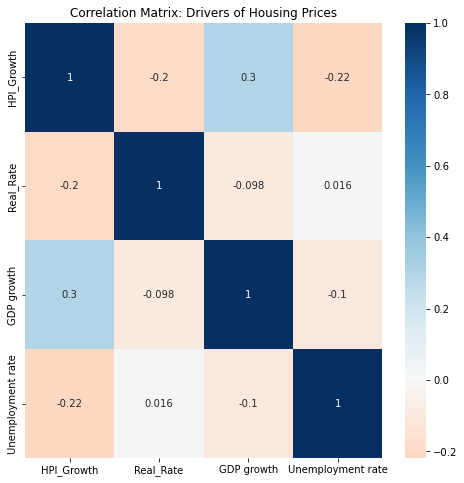

In [93]:
# Plotting
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix: Drivers of Housing Prices')
plt.show()

**Interpretation of heatmap**:  
The heatmap demonstrates the correlation (*r*) of the different variables in the analysis. Looking at the variables that concern $H_1$ - Real_Rate (of interests) and the HPI growth - we do indeed confirm a general negative correlation of *-0.2*. Additionally, there is a positive correlation between GDP growth and HPI growth - that suggests that economic expansion boosts property values. 

#### 2. Violin Plot (Showing $H_2$ volatility)  
Looking into the behavoiur of the 30 developed verses the 6 Developing countries

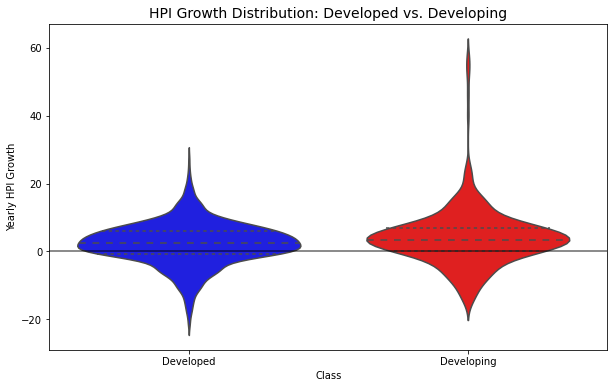

In [94]:
# plotting the violin
my_colours = {"Developed": "blue", "Developing": "red"}
plt.figure(figsize=(10, 6))
sns.violinplot(data=Project_Data, x='Class', y='HPI_Growth',palette = my_colours, inner="quartile")
plt.title('HPI Growth Distribution: Developed vs. Developing', fontsize=14)
plt.ylabel('Yearly HPI Growth')
plt.axhline(0, color='black', linestyle='-', alpha=0.6)
plt.show()

##### Interpretations of the violin plot 
The violin plot aims to display volatility of both classes. Developed countries show consistency - concentrated density, while the Developing have a much wider variance in outcomes. The higher "tail" of the Developing class may suggest that other factors than interest rates play a bigger part in the behaviour of housing prices.

#### 3. Time plot  
I am interested to see how housing markets and interest rate moved through the decade, especially as COVID-19 hit the world.

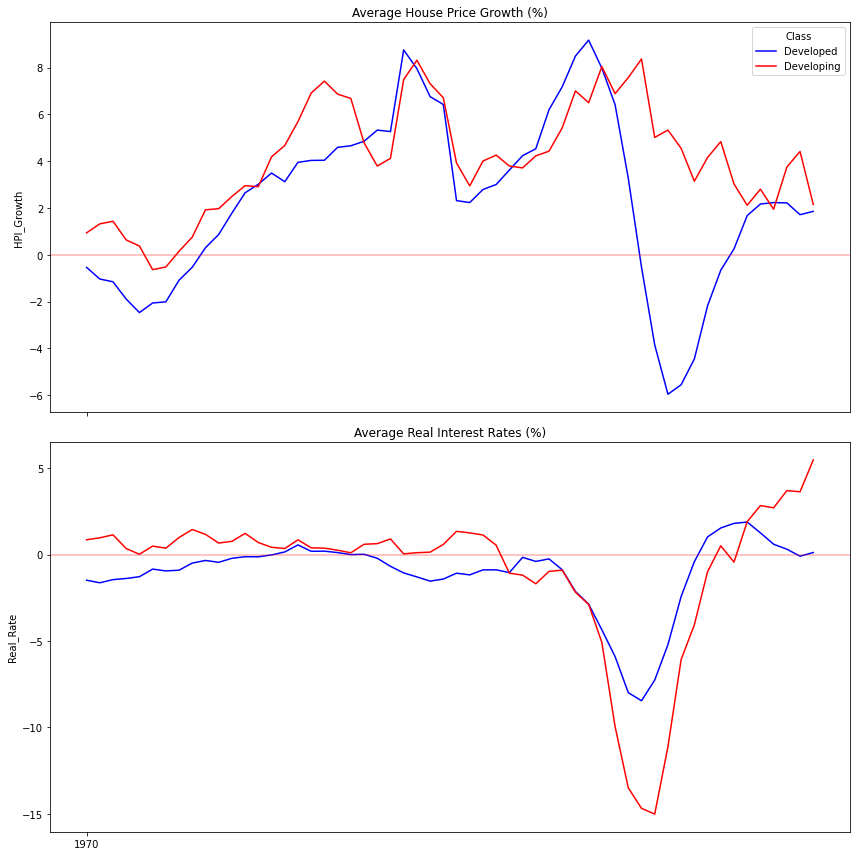

In [95]:
# using the average trends
averages = Project_Data.groupby(['Quarter', 'Class'])[['HPI_Growth', 'Real_Rate']].mean().reset_index()

#  two stacked plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot 1: House Price Growth
sns.lineplot(data=averages, x='Quarter', y='HPI_Growth', hue='Class', ax=ax1, palette = my_colours)
ax1.set_title('Average House Price Growth (%)')
ax1.axhline(0, color='red', linestyle='-', alpha=0.3)
ax1.set_xlabel('')

# Plot 2: Real Interest Rates
sns.lineplot(data=averages, x='Quarter', y='Real_Rate', hue='Class', ax=ax2,palette = my_colours, legend=False)
ax2.set_title('Average Real Interest Rates (%)')
ax2.axhline(0, color='red', linestyle='-', alpha=0.3)
ax2.set_xlabel('')

ax2.xaxis.set_major_locator(mdates.YearLocator(2)) 
# Format the date to show just the year
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Slightly rotate them for extra clarity
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Interpretation for the time plot**:  
The graphs demonstrates that there is a "growth gap" between the two classes. Developing economies show a higher average growth rate, which suggests that they provide higher returns but are more susceptible to change and therefore loss.  

Developed economies, while having a modest growth, it is consistent. 

I want to plot the two variables - HPI growth and interest rate for each class to see if the effect is more visible in one of the groups. That wold be able to be spotted by the two lines swaying in opposite directions.

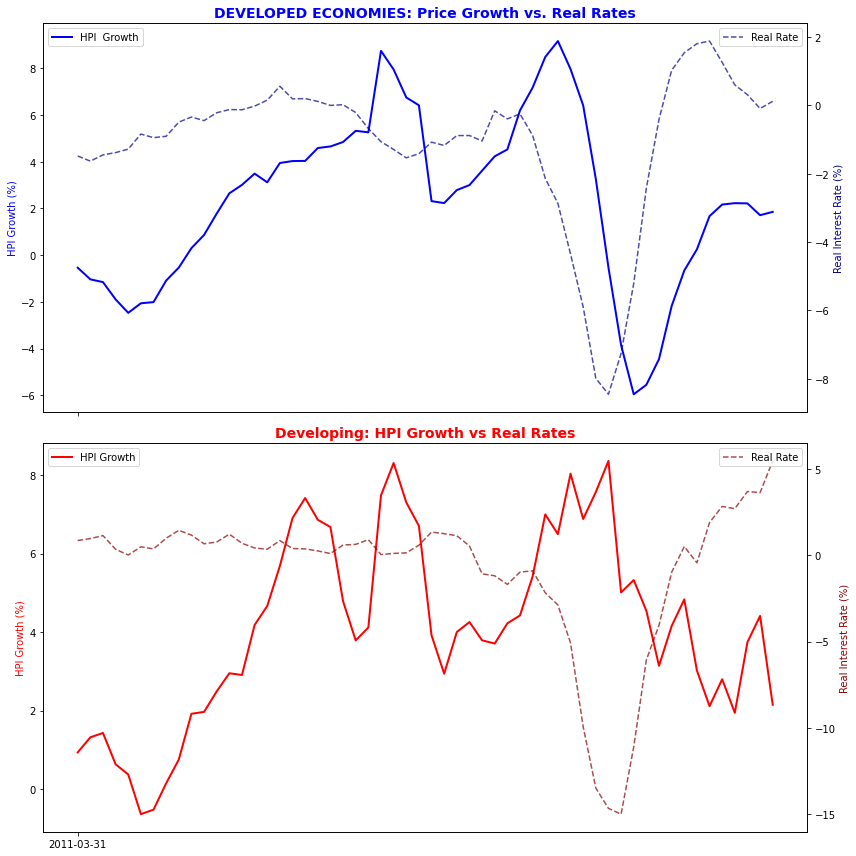

In [96]:
#Averages for each class
averages_class = Project_Data.groupby(['Quarter','Class'])[['HPI_Growth', 'Real_Rate']].mean().reset_index()

# two subplots
fig, (ax1,ax2) = plt.subplots(2,1,figsize = (12,12),sharex = True)

#1st subplot - Developed
developed_data = averages_class[averages_class['Class'] == 'Developed']
ax1.plot(developed_data['Quarter'],developed_data['HPI_Growth'], color = 'blue', label = 'HPI  Growth', linewidth = 2)
ax1_twin = ax1.twinx()
ax1_twin.plot(developed_data['Quarter'], developed_data['Real_Rate'], color='darkblue', label='Real Rate', linestyle='--', alpha=0.7)

#looks
ax1.set_title('DEVELOPED ECONOMIES: Price Growth vs. Real Rates', fontsize=14, fontweight='bold', color='blue')
ax1.set_ylabel('HPI Growth (%)', color='blue')
ax1_twin.set_ylabel('Real Interest Rate (%)', color='darkblue')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

#2nd plot - developing
developing_data = averages_class[averages_class['Class'] == 'Developing']
ax2.plot(developing_data['Quarter'], developing_data['HPI_Growth'], color='red', label='HPI Growth', linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(developing_data['Quarter'], developing_data['Real_Rate'], color='darkred', label='Real Rate', linestyle='--', alpha=0.7)

#looks
ax2.set_title('Developing: HPI Growth vs Real Rates', fontsize=14, fontweight='bold', color='red')
ax2.set_ylabel('HPI Growth (%)', color='red')
ax2_twin.set_ylabel('Real Interest Rate (%)', color='darkred')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

**Interpretations**:  
Comparative Dynamics($H_2$):  
Looking at the plots, Developed economies show a higher reach in HPI growth. That may be due to higher efficiency of the their banking system and by proxy mortgage market. When real interest rates hit 0% or went negative (as seen in the blue chart), it allowed people to take out massive loans, which "fueled" the huge price spikes observed (reaching nearly 15%). That means that low real rates translate almost instantly into massive property demand.  

Inversely, developing economies show a much higher spread in real interest rates. Despite wild swings in the real interest rate, their housing markets appear 'less synchronized' with the rates. This suggests that in developing markets prices might be driven more by supply constraints or local economic shocks than by the central bank's interest rate tool alone. This supports the hypothesis that the 'sensitivity' to interest rates is structurally different across the two classes.  

This is the time to mention **time lags** in reaction - housing markets are no wall street and they take their time to react to the economic state around them.

#### 4. Lag Analysis  

While our previous visualizations show a clear inverse relationship between real interest rates and housing prices, economic theory suggests that the impact of monetary policy is not instant. This delay, known as a **time lag** happens for a few reasons:  
1. Delays in contract - it takes time for a banks offer for mortgages to expire and for them to implement a higher rate to reflect the new buyer behaviour
2. Market behaviour - sellers don't immediately adjust the price they are willing to take for their property, they wait a while to accept that the demand and therefore price has changed

We will use a Cross-Correlation analysis to determine how long is the peak reaction time. We will shift the real interest rate variable with *k* quarters so we can identify exactly how long it takes for a change in the interest rates to make a change on the HPI across both classes. For this analysis I will calculate correlation for different lags - from 0 to 4 quarters grace period. 

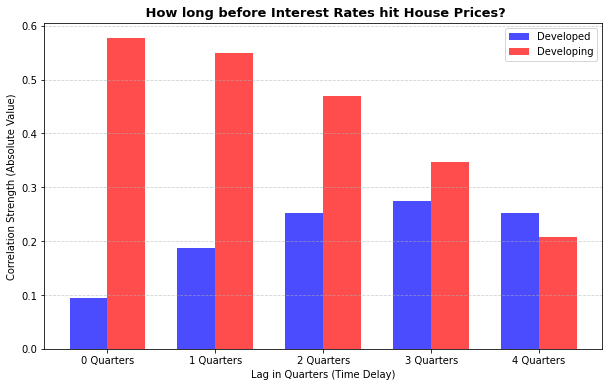

In [97]:
# correlations for the diff lags
lags = [0,1,2,3,4]
developed_correlations = []
developing_correlations=[]

for lag in lags:
    # Shift the Real Rate by the lag amount for each group
    # A negative correlation is expected (as rates go up, prices go down)
    developed_val = Project_Data[Project_Data['Class'] == 'Developed']['HPI_Growth'].corr(Project_Data[Project_Data['Class'] == 'Developed']['Real_Rate'].shift(lag))
    developing_val = Project_Data[Project_Data['Class'] == 'Developing']['HPI_Growth'].corr(Project_Data[Project_Data['Class'] == 'Developing']['Real_Rate'].shift(lag))
     # Using absolute value to show the pull
    developed_correlations.append(abs(developed_val))
    developing_correlations.append(abs(developing_val))

# Plot the results
plt.figure(figsize=(10, 6))
x = range(len(lags))
width = 0.35

plt.bar([i - width/2 for i in x], developed_correlations, width, label='Developed', color='blue', alpha=0.7)
plt.bar([i + width/2 for i in x], developing_correlations, width, label='Developing', color='red', alpha=0.7)

plt.xlabel('Lag in Quarters (Time Delay)')
plt.ylabel('Correlation Strength (Absolute Value)')
plt.title(' How long before Interest Rates hit House Prices?', fontsize=13, fontweight='bold')
plt.xticks(x, [f'{l} Quarters' for l in lags])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


**Interpretations**:  
The lag reaction graph demonstrates a fundamental difference in market behaviour. Developed countries, where while the banking system is stable, it's rather slow and thus the reaction to the change of interest rate is slower - peaking at 3 quarters or 9 months. The prolonged duration may be of legal transfers of properties and the formal closing of the documentation.  

Inversely, Developing countries show a much stronger 'shock-response' to the change of interest rate. Their strongest reaction is at 0-1 quarters. The rather quick disintegration of the strength may sudjest that these economies lack 'buffers' that soften the reaction of changing economic variables like the interest rate. 

### Testing Hypothesis 1 ($H_1$)
There is a significant inverse relationship where higher rates lead to lower price growth

After the visualization of data we move to the mathematical part of this analysis. During the previous section we identified a 9-month peak transmission lag for developed economies and 1-3 month peak for developing economies.  

The aim of this section is to try and isolate the effect of the real interest rates on the residential house price growth while taking into consideration other economic factors - GDP growth and unemployment. Using a linear regression alongside the lags of reaction, I will test if $H_1$ is true across the world.

#### Simple Regression Model
First, I will test a more simple method, without testing with the time lags to see if there is a general link between interest rates and housing prices

'Simple' Regression Model:

$$HPI\_Growth_{t} = \beta_0 + \beta_1(Real\_Rate_{t}) + \beta_2(GDP\_growth_{t}) + \beta_3(Unemployment\_rate_{t}) + \epsilon$$

In [113]:
#so, because I named some of my columns with space between, it crashes the formula, so:
Project_Data = Project_Data.rename(columns = {'GDP growth': 'GDP_Growth', 'Unemployment rate':'Unemployment_Rate', 'Class Numeric':'Class_Numeric' })


h1_simple = smf.ols(formula = "HPI_Growth ~ Real_Rate + GDP_Growth + Unemployment_Rate", data=Project_Data).fit()
# I also want the t-test
t_test_results = pd.DataFrame({
    't-value': h1_simple.tvalues,
    'P-value': h1_simple.pvalues
})

print("-------Simple H_1 Model--------")
print("--- Coefficients ---")
print(h1_simple.params)

print("--- P-Values ---")
print(h1_simple.pvalues.round(15))

print("----T-test----")
print(t_test_results.round(3))

print(f"--- R-squared: {h1_simple.rsquared:.4f} ---")

-------Simple H_1 Model--------
--- Coefficients ---
Intercept            3.599614
Real_Rate           -0.266039
GDP_Growth           0.444274
Unemployment_Rate   -0.312215
dtype: float64
--- P-Values ---
Intercept            0.000000e+00
Real_Rate            2.000000e-15
GDP_Growth           0.000000e+00
Unemployment_Rate    0.000000e+00
dtype: float64
----T-test----
                   t-value  P-value
Intercept           11.985      0.0
Real_Rate           -8.012      0.0
GDP_Growth          12.469      0.0
Unemployment_Rate   -9.024      0.0
--- R-squared: 0.1511 ---


**Meaning and Interpretations**:  
1. **Coefficient ($\beta$)**: The coefficient represents the mean change in the dependent variable, in our case that is the HPI growth, for every 1% change in the independent variable, which here is the Real Rate, holding everything else constant.

   **Result**: Our model resulted a coefficient of -0.266039 for the Real_Rate. This basically means that for every 1% increase of the real interest rate, house price growth decreases by 0.26%. This negative relation between the interest rate and property prices is a strong indicator of the $H_1$'s legitimacy.
   
2. **P-value**: The p-value represents that the observed relationship occurred by pure chance or not. In statistics, a p-value below 0.05 is considered "statistically significant". A low p-value shows that the observed relationship would be unlikely to happen under the null hypothesis.

   **Result**: The P-value for all variables are 0.0000, except for the real_rate which is 0.000000000000002. This indicates that there probability that the variable have no actual effect on housing prices is statistically negligible. As a consequence, we can **reject the null hypothesis with a 99.9% confidence level**, which suggests that there is a real relationship  rather than pure chance.
   
3. **T-test**: The t-statistic evaluates if the relationship is large relative to its standard error, indicating statistical significance. The t-test is the coefficient divided by the standard error. A t-value bigger than 2 and less than -0.2 means that the variable is reliable and the results aren't random.

   **Result**:The Real_Rate showed a t-value of -11.854. That is very high absolute value, which points to the direction that the relation between interest rates and housing prices is robust.
   
4. **R-squared($R^2$)**: The $R^2$ measures the proportion of variation in the dependent variable that is explained by the independent variable. It ranges form 0 to 1, where 1 indicates that the model explains 100% of the change in the dependent variable.

   **Result**: The model showcases an $R^2$ of 0.15. This means that 15% of the global housing fluctuations is directly explained by the change of Real interest rates, GDP and Unemployment. That may seem small, but it just means that a larger chunk of price change is because of local factors that are not captured in the model - housing supply for an example.  


#### Universal Lag Model  

In the Simple Regression Model we found that a relationship exists, but we omitted the  time for markets to adjust - their lags. We did that to just generally look if there is a relation, but in this part, after cross-correlation analysis we did, the data revealed a more complex reaction from the two classes of economies. Developed economies reaction peaked at 3 quarters or 9 months, while Developing Economies reacted immediately.   

To test $H_1$ we will take the mean of the 2 reactions by giving the data a 3 month lag. We would be able to see the cause with the effect much more clearly. If $H_1$ is true, this model should show a tighter correlation that the simple one. 

In [111]:
# making a 3 month (1 Q) lag for everyone
Project_Data['Real_Rate_Lag'] = Project_Data.groupby('Country')['Real_Rate'].shift(1)

h1_lag_model = smf.ols(formula = "HPI_Growth ~ Real_Rate_Lag + GDP_Growth + Unemployment_Rate", data=Project_Data.dropna(subset=['Real_Rate_Lag'])).fit()
# we use dropna because of the Nan values that happen when we shift data 
#Results
print("------- Global 1-Quarter Lag Model --------")
print(f"Coefficient: {h1_lag_model.params['Real_Rate_Lag']:.4f}")
print(f"t-value:     {h1_lag_model.tvalues['Real_Rate_Lag']:.3f}")
print(f"P-value:     {h1_lag_model.pvalues['Real_Rate_Lag']:.5f}")
print(f"R-squared:   {h1_lag_model.rsquared:.4f}")


------- Global 1-Quarter Lag Model --------
Coefficient: -0.1933
t-value:     -5.768
P-value:     0.00000
R-squared:   0.1372


1. **The Regression Coefficient ($\beta$)**: Real_Rate coefficient moved from -0.266 to -0.193. While still negative and confirming $H_1$, this suggests that a 1% change in rates has a more immediate "sharp" impact on prices than it does a "delayed" one when looking at the global average.
This implies that some markets, more likely Developing ones, reacted so fast that a global 3-month lag "misses" the peak of the impact.

2. **The t-test:** The t-value dropped from -8.01 to -5.76, which is still above the significance threshold (2), but the reduction suggest that maybe a 3-month lag is not ideal for either class. The compromise of a 3-month lag misses both the peak of developing countries that have a very fast reaction time and by 3 months the effect is dwindling and the peak of developed economies as they need more time to sufficiently react, so 3-moths is early.

3. **R-squared:** the R-squared value also dropped, going form 0.15 to 0.13. That is largely of the insufficient idea that a 3 month lag would explain the behaviour of both groups, while in reality it fails to capture the real effect in the pursuit of capturing the mean and as a result missing both. 


By forcing a 3-month delay on the entire dataset, we have effectively 'misaligned' the model for countries that react instantaneously. This confirms that a universal lag is an insufficient tool for global analysis and necessitates the use of the Hybrid Lag Model to separate the fast-reacting Developing economies from the slow-reacting Developed ones. 

#### Hybrid Lag Model

From the Universal Lag Analysis we came to the conclusion that a 3-month universal lag is too slow of a time for Developed economies to react and not fast enough to capture the highs of the Developing economies.   

We have already came to the conclusion that there is an inverse relation between interest rates and housing prices in the simple regression model and  from the Cross-Analysis we did confirm that the price altering effect of interest rates take different time to 'hit' the housing market. To finally, come to a definitive conclusion for $H_1$, we will apply 2 different lags for each economy type.  
The motive behind doing this is the following: the hypothesis just says that there is an inverse relation, not how long it takes. We have already established that for the two economies that is different amount of time, so we will factor that in to get a clear picture of the relation interest rates - housing price growth. 

In [109]:
# developed data; using a lag of 3 quarters
developed_data_lag = Project_Data[Project_Data['Class_Numeric'] == 1].copy()
developed_data_lag ['Real_Lag_3'] = developed_data_lag.groupby('Country')['Real_Rate'].shift(3)

h1_developed = smf.ols(formula = "HPI_Growth ~ Real_Lag_3 + GDP_Growth + Unemployment_Rate", data=developed_data_lag.dropna(subset=['Real_Lag_3'])).fit()

# developing data; using a lag of 0 quarters
developing_data_lag = Project_Data[Project_Data['Class_Numeric'] == 0].copy()
developing_data_lag ['Real_Lag_0'] = developing_data_lag.groupby('Country')['Real_Rate'].shift(0)

h1_developing = smf.ols(formula = "HPI_Growth ~ Real_Lag_0 + GDP_Growth + Unemployment_Rate", data=developing_data_lag.dropna(subset=['Real_Lag_0'])).fit()

#Results
print("------ DEVELOPED ECONOMIES (9-Month Lag) ------")
print(f"R-squared: {h1_developed.rsquared:.4f}")
print(h1_developed.summary2().tables[1][['Coef.', 't', 'P>|t|']].round(4))

print("------DEVELOPING ECONOMIES (0-Month Lag)------")
print(f"R-squared: {h1_developing.rsquared:.4f}")
print(h1_developing.summary2().tables[1][['Coef.', 't', 'P>|t|']].round(4))

------ DEVELOPED ECONOMIES (9-Month Lag) ------
R-squared: 0.2152
                    Coef.        t  P>|t|
Intercept          4.7249  15.6115    0.0
Real_Lag_3         0.6377  12.7005    0.0
GDP_Growth         0.4024  10.9569    0.0
Unemployment_Rate -0.3200  -9.4330    0.0
------DEVELOPING ECONOMIES (0-Month Lag)------
R-squared: 0.3913
                    Coef.        t   P>|t|
Intercept          6.3258   6.6044  0.0000
Real_Lag_0        -0.6030 -13.2211  0.0000
GDP_Growth         0.3098   3.6327  0.0003
Unemployment_Rate -0.5112  -4.4092  0.0000


Interpretations:

#### $H_1$ Conclusion

### Testing Hypothesis 2 ($H_2$)
Sensitivity to the interest rate changes felt in the housing market in "Developed" countries is higher than in "Developing" countries

In [151]:
developed_data_lag['Hybrid_Rate'] = developed_data_lag['Real_Lag_3']
developing_data_lag['Hybrid_Rate'] = developing_data_lag['Real_Lag_0']

#attach the 2 dataframes
combined_stats = pd.concat([developed_data_lag, developing_data_lag])

#making them readable at the end
combined_stats['Status'] = combined_stats['Class_Numeric'].map({0: 'Developing', 1: 'Developed'})

# testing the interaction model
h2_model = smf.ols(
    formula = "HPI_Growth ~ Hybrid_Rate * C(Status, Treatment('Developing')) + GDP_Growth + Unemployment_Rate", data = combined_stats).fit()

# loaded the full summary, so confusing, so:
summary_named = h2_model.summary2().tables[1][['Coef.', 't', 'P>|t|']]

# readable names are quite hard ig
summary_named.index = [
    'Intercept',
    'Base Premium (Developed vs Developing)',
    'Interest Rate Impact (Developing)',
    'Difference in Impact (Developed vs Developing)',
    'GDP Growth Impact',
    'Unemployment Impact'
]
print(f"-----Hypothesis 2: Interaction Model Results-------")
print(f"R-squared: {h2_model.rsquared:.4f}")
print("-" * 51)
print(summary_named.round(4))
print("-" * 51)

-----Hypothesis 2: Interaction Model Results-------
R-squared: 0.2714
---------------------------------------------------
                                                 Coef.        t   P>|t|
Intercept                                       4.8963  11.6066  0.0000
Base Premium (Developed vs Developing)          0.0544   0.1518  0.8793
Interest Rate Impact (Developing)              -0.5936 -15.5010  0.0000
Difference in Impact (Developed vs Developing)  1.2376  18.9989  0.0000
GDP Growth Impact                               0.3784  11.1795  0.0000
Unemployment Impact                            -0.3449 -10.3663  0.0000
---------------------------------------------------


Interpretations:

**The Intercept ($\beta = 4.8963, p < 0.001$)**:  
The intercept shows a growth of 4.90% for global housing prices when all economic predictors in the analysis, interest rates, GDP growth, and unemployment, are held at zero. This represents the inherent "organic" demand within the housing sector driven by exogenous to the analysis factors such as urbanization and population growth.  

**Base Premium for Developed Economies ($\beta = 0.0544, p = 0.879$):**  
This is the coefficient for the dummy variable we introduced. The p-value shows that it is statistically insignificant - that suggests that Developed countries don't just "automatically" grow faster than Developing ones.  

**Baseline Interest Rate Impact (Developing) ($\beta = -0.5936, p < 0.001$):**  
For Developing nations the results reflect the textbook notion that when interest rates go up, prices lower. For every 1% increase in the real interest rate, house price growth drops by 0.59%. That translates to a market that is very sensitive to the cost of borrowing.  

**Interaction Term: Divergence in Impact ($\beta = 1.2376, p < 0.001$):**  
The coefficient is positive and highly significant as the t-value is 18.99, indicating a profound divergence. It shows that being a Developed country adds a +1.237 "buffer" to the interest rate effect. Because this number is positive and much larger than the negative impact, it cancels out the "pain" of the rate hike. It proves that Developed markets are much more resilient to changes in the interest rate.

**GDP Growth Impact ($\beta = 0.3784, p < 0.001$):**  
Also true in economic theory, GDP growth is an engine. The coefficient shows that for every 1% growth in the economy, housing prices rise by 0.378% across all economies.  

**Unemployment Impact ($\beta = -0.3449, p < 0.001$):**
Unemployment has proven to be a strong indicator of housing prices dropping. For every 1% increase of people not employed, housing prices drop by 0.34. This shows us that jobs security is a big factor for people when making the decision to buy a residential property.  


### Scope and Assumptions: 
Developing countries don't always have the most reliant data. Those countries also have more recent data, so our scope will be in the 21st century (2010-2025)

### Limitations
Data for Developing nations can be less frequent or subject to revisions. Furthermore, my analysis assumes that central bank policy rates are a reliable proxy for mortgage market conditions.